# Tutorial 07 — Transfer Learning: Feature Extraction vs Fine-Tuning

## Objective

This notebook implements **Tutorial 07: Compare Feature Extraction vs. Fine-Tuning** using PyTorch.

The tutorial covers:

- Transfer learning concepts
- Feature extraction
- Fine-tuning
- Working with pretrained models
- CIFAR-10 classification
- Comparing pretrained models with a custom CNN
- Improving fine-tuning results

Main experiments:

1. Custom CNN trained from scratch
2. VGG16 feature extraction
3. ResNet50 fine-tuning
4. ResNet50 feature extraction
5. VGG16 fine-tuning
6. Improved ResNet50 fine-tuning


## 1. Import Required Libraries

In [25]:
import os
import time
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

os.makedirs("images", exist_ok=True)


PyTorch version: 2.5.1+cu121
CUDA available: True
Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## 2. Settings

Pretrained models such as VGG16 and ResNet50 are heavier than the models used in previous tutorials.

`USE_SUBSET = True` keeps training time practical. For full CIFAR-10 training, change it to `False`.

If you get a CUDA memory error, reduce `BATCH_SIZE` from 32 to 16.


In [26]:
USE_SUBSET = True
TRAIN_SUBSET_SIZE = 8000
VAL_SUBSET_SIZE = 2000
TEST_SUBSET_SIZE = 2000

BATCH_SIZE = 32
NUM_EPOCHS_MAIN = 3
NUM_EPOCHS_IMPROVED = 5

print("USE_SUBSET:", USE_SUBSET)
print("Batch size:", BATCH_SIZE)


USE_SUBSET: True
Batch size: 32


## 3. Load and Preprocess CIFAR-10

CIFAR-10 has 10 classes:

- airplane
- automobile
- bird
- cat
- deer
- dog
- frog
- horse
- ship
- truck

Pretrained ImageNet models expect ImageNet-style preprocessing, so the CIFAR-10 images are resized to `224 × 224` and normalized with ImageNet mean and standard deviation.


In [27]:
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

display_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_full_dataset = datasets.CIFAR10(root="./data", train=True, download=True, transform=train_transform)
val_full_dataset = datasets.CIFAR10(root="./data", train=True, download=True, transform=test_transform)
test_dataset_full = datasets.CIFAR10(root="./data", train=False, download=True, transform=test_transform)
display_dataset = datasets.CIFAR10(root="./data", train=True, download=True, transform=display_transform)

print("Full training samples:", len(train_full_dataset))
print("Full test samples:", len(test_dataset_full))


Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Full training samples: 50000
Full test samples: 10000


## 4. Create Training, Validation, and Test Loaders

In [28]:
num_train = len(train_full_dataset)
indices = np.arange(num_train)
np.random.seed(SEED)
np.random.shuffle(indices)

if USE_SUBSET:
    train_indices = indices[:TRAIN_SUBSET_SIZE]
    val_indices = indices[TRAIN_SUBSET_SIZE:TRAIN_SUBSET_SIZE + VAL_SUBSET_SIZE]
    test_indices = np.arange(len(test_dataset_full))
    np.random.seed(SEED)
    np.random.shuffle(test_indices)
    test_indices = test_indices[:TEST_SUBSET_SIZE]
else:
    val_size = 5000
    val_indices = indices[:val_size]
    train_indices = indices[val_size:]
    test_indices = np.arange(len(test_dataset_full))

train_dataset = Subset(train_full_dataset, train_indices)
val_dataset = Subset(val_full_dataset, val_indices)
test_dataset = Subset(test_dataset_full, test_indices)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Testing samples:", len(test_dataset))


Training samples: 8000
Validation samples: 2000
Testing samples: 2000


## 5. Visualize CIFAR-10 Samples

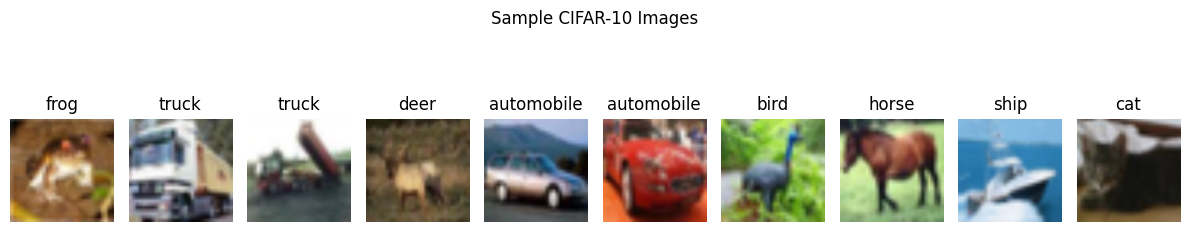

In [29]:
def show_cifar_samples(dataset, n_images=10):
    plt.figure(figsize=(12, 3))
    for i in range(n_images):
        image, label = dataset[i]
        image_np = image.permute(1, 2, 0).numpy()
        plt.subplot(1, n_images, i + 1)
        plt.imshow(image_np)
        plt.title(class_names[label])
        plt.axis("off")
    plt.suptitle("Sample CIFAR-10 Images")
    plt.tight_layout()
    plt.savefig("images/tutorial_07_cifar10_samples.png", dpi=300, bbox_inches="tight")
    plt.show()

show_cifar_samples(display_dataset, n_images=10)


## 6. Helper Functions

In [30]:
def train_one_epoch(model, data_loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in data_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total


def evaluate_one_epoch(model, data_loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    return running_loss / total, correct / total


def train_model(model, train_loader, val_loader, optimizer_name="adam", learning_rate=0.001,
                epochs=3, weight_decay=0.0, early_stopping=False, patience=3, verbose=True):
    criterion = nn.CrossEntropyLoss()
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    if optimizer_name.lower() == "adam":
        optimizer = torch.optim.Adam(trainable_params, lr=learning_rate, weight_decay=weight_decay)
    elif optimizer_name.lower() == "sgd":
        optimizer = torch.optim.SGD(trainable_params, lr=learning_rate, momentum=0.9, weight_decay=weight_decay)
    elif optimizer_name.lower() == "rmsprop":
        optimizer = torch.optim.RMSprop(trainable_params, lr=learning_rate, weight_decay=weight_decay)
    else:
        raise ValueError("optimizer_name must be 'adam', 'sgd', or 'rmsprop'")
    history = {"train_loss": [], "val_loss": [], "train_accuracy": [], "val_accuracy": [], "epoch_time": []}
    best_val_loss = float("inf")
    best_model_state = copy.deepcopy(model.state_dict())
    patience_counter = 0
    start_time = time.time()
    for epoch in range(epochs):
        epoch_start = time.time()
        train_loss, train_accuracy = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_accuracy = evaluate_one_epoch(model, val_loader, criterion)
        epoch_time = time.time() - epoch_start
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_accuracy"].append(val_accuracy)
        history["epoch_time"].append(epoch_time)
        if verbose:
            print(f"Epoch {epoch + 1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Train Acc: {train_accuracy * 100:.2f}% | Val Acc: {val_accuracy * 100:.2f}%")
        if early_stopping:
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_state = copy.deepcopy(model.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1
            if patience_counter >= patience:
                if verbose:
                    print(f"Early stopping triggered at epoch {epoch + 1}")
                break
    total_time = time.time() - start_time
    if early_stopping:
        model.load_state_dict(best_model_state)
    return history, total_time


def get_predictions(model, data_loader):
    model.eval()
    all_predictions = []
    all_labels = []
    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_predictions)


def plot_training_history(history, title, filename):
    epochs_range = range(1, len(history["train_loss"]) + 1)
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history["train_accuracy"], label="Train Accuracy")
    plt.plot(epochs_range, history["val_accuracy"], label="Val Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history["train_loss"], label="Train Loss")
    plt.plot(epochs_range, history["val_loss"], label="Val Loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


def save_dataframe_as_image(df, filename, title=None):
    fig_width = max(8, len(df.columns) * 2.0)
    fig_height = max(2.5, len(df) * 0.45 + 1.2)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis("off")
    table = ax.table(cellText=df.values, colLabels=df.columns, cellLoc="center", loc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.4)
    if title:
        ax.set_title(title, fontsize=12, pad=12)
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def count_total_parameters(model):
    return sum(p.numel() for p in model.parameters())


# Part A — Custom CNN Baseline

A custom CNN is trained from scratch to provide a baseline for comparison with pretrained transfer learning models.


In [31]:
class CustomCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((4, 4))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 10)
        )
    def forward(self, x):
        return self.classifier(self.features(x))


torch.manual_seed(SEED)
custom_model = CustomCNN().to(device)
print(custom_model)
print("Total parameters:", count_total_parameters(custom_model))
print("Trainable parameters:", count_trainable_parameters(custom_model))


CustomCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): AdaptiveAvgPool2d(output_size=(4, 4))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)
Total parameters: 620362
Trainable parameters: 620362


In [32]:
custom_history, custom_time = train_model(
    custom_model, train_loader, val_loader,
    optimizer_name="adam", learning_rate=0.001,
    epochs=NUM_EPOCHS_MAIN, weight_decay=1e-4,
    early_stopping=False, verbose=True
)
plot_training_history(custom_history, "Custom CNN", "images/tutorial_07_custom_cnn_curves.png")
y_true_custom, y_pred_custom = get_predictions(custom_model, test_loader)
custom_test_accuracy = accuracy_score(y_true_custom, y_pred_custom)
print("Custom CNN Test Accuracy:", round(custom_test_accuracy * 100, 2), "%")
print("Training time:", round(custom_time, 2), "seconds")


KeyboardInterrupt: 

# Part B — VGG16 Feature Extraction

In feature extraction, the pretrained VGG16 convolutional base is frozen and only the new classification layers are trained.


In [ ]:
def build_vgg16_feature_extractor():
    weights = models.VGG16_Weights.DEFAULT
    model = models.vgg16(weights=weights)
    for param in model.features.parameters():
        param.requires_grad = False
    in_features = model.classifier[0].in_features
    model.classifier = nn.Sequential(
        nn.Linear(in_features, 512), nn.ReLU(), nn.Dropout(0.5), nn.Linear(512, 10)
    )
    return model


torch.manual_seed(SEED)
vgg16_feature_model = build_vgg16_feature_extractor().to(device)
print("VGG16 Feature Extraction")
print("Total parameters:", count_total_parameters(vgg16_feature_model))
print("Trainable parameters:", count_trainable_parameters(vgg16_feature_model))


VGG16 Feature Extraction
Total parameters: 27565386
Trainable parameters: 12850698


Epoch 1/3 | Train Loss: 0.8221 | Val Loss: 0.5079 | Train Acc: 72.50% | Val Acc: 82.40%
Epoch 2/3 | Train Loss: 0.4601 | Val Loss: 0.4658 | Train Acc: 84.20% | Val Acc: 84.50%
Epoch 3/3 | Train Loss: 0.3559 | Val Loss: 0.5143 | Train Acc: 88.09% | Val Acc: 82.80%


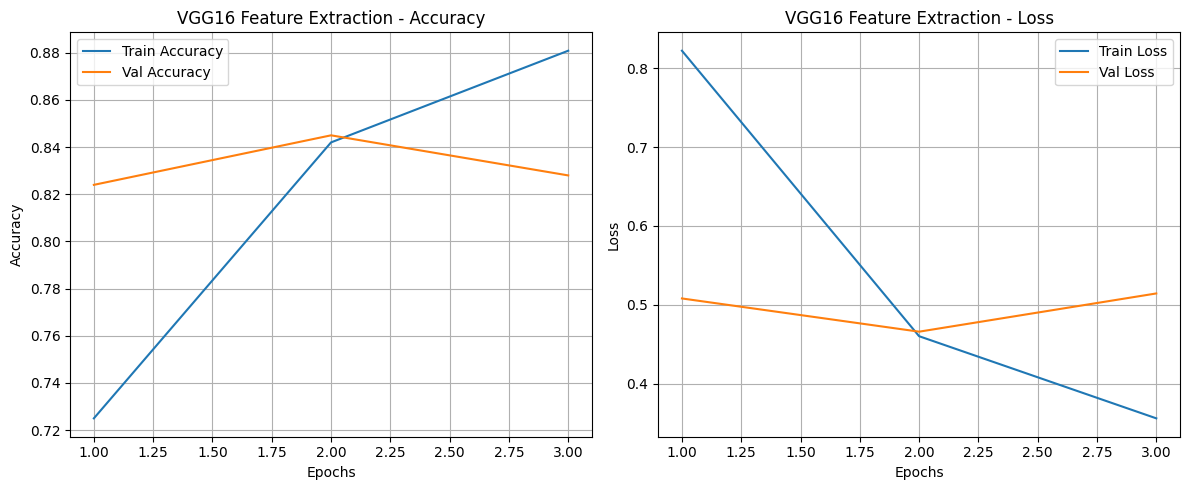

VGG16 Feature Extraction Test Accuracy: 82.25 %
Training time: 186.29 seconds


In [ ]:
vgg16_feature_history, vgg16_feature_time = train_model(
    vgg16_feature_model, train_loader, val_loader,
    optimizer_name="adam", learning_rate=0.001,
    epochs=NUM_EPOCHS_MAIN, weight_decay=1e-4,
    early_stopping=False, verbose=True
)
plot_training_history(vgg16_feature_history, "VGG16 Feature Extraction", "images/tutorial_07_vgg16_feature_extraction_curves.png")
y_true_vgg_fe, y_pred_vgg_fe = get_predictions(vgg16_feature_model, test_loader)
vgg16_feature_test_accuracy = accuracy_score(y_true_vgg_fe, y_pred_vgg_fe)
print("VGG16 Feature Extraction Test Accuracy:", round(vgg16_feature_test_accuracy * 100, 2), "%")
print("Training time:", round(vgg16_feature_time, 2), "seconds")


# Part C — ResNet50 Fine-Tuning

In fine-tuning, the final classifier is replaced and the last ResNet block is unfrozen along with the new classifier.


In [ ]:
def build_resnet50_finetune(unfreeze_layer4=True):
    weights = models.ResNet50_Weights.DEFAULT
    model = models.resnet50(weights=weights)
    for param in model.parameters():
        param.requires_grad = False
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, 10)
    if unfreeze_layer4:
        for param in model.layer4.parameters():
            param.requires_grad = True
    for param in model.fc.parameters():
        param.requires_grad = True
    return model


torch.manual_seed(SEED)
resnet50_finetune_model = build_resnet50_finetune(unfreeze_layer4=True).to(device)
print("ResNet50 Fine-Tuning")
print("Total parameters:", count_total_parameters(resnet50_finetune_model))
print("Trainable parameters:", count_trainable_parameters(resnet50_finetune_model))


ResNet50 Fine-Tuning
Total parameters: 23528522
Trainable parameters: 14985226


Epoch 1/3 | Train Loss: 1.0486 | Val Loss: 0.4903 | Train Acc: 68.80% | Val Acc: 83.85%
Epoch 2/3 | Train Loss: 0.4211 | Val Loss: 0.4261 | Train Acc: 86.36% | Val Acc: 85.70%
Epoch 3/3 | Train Loss: 0.2446 | Val Loss: 0.4285 | Train Acc: 92.16% | Val Acc: 85.80%


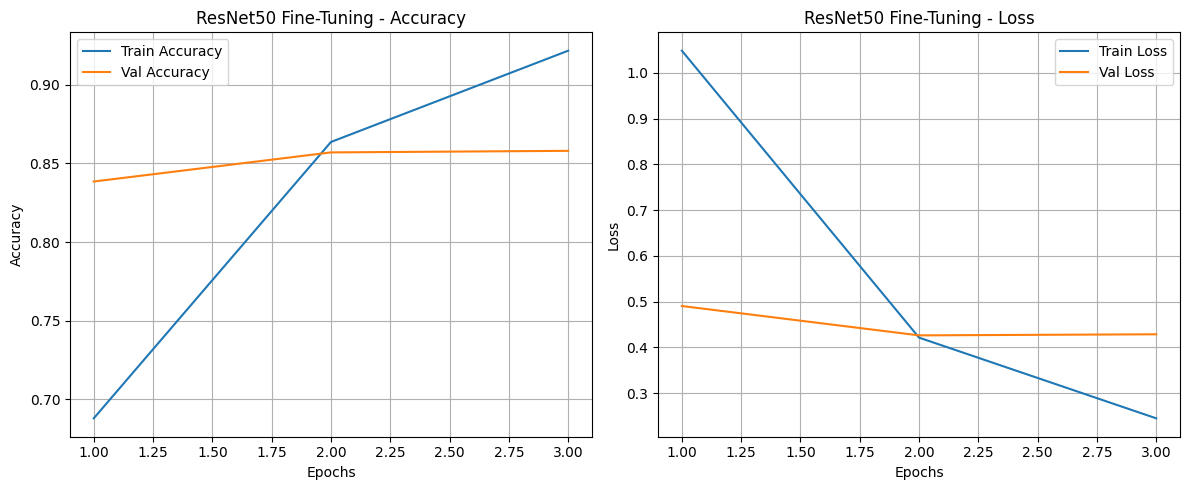

ResNet50 Fine-Tuning Test Accuracy: 85.8 %
Training time: 133.16 seconds


In [ ]:
resnet50_finetune_history, resnet50_finetune_time = train_model(
    resnet50_finetune_model, train_loader, val_loader,
    optimizer_name="adam", learning_rate=1e-4,
    epochs=NUM_EPOCHS_MAIN, weight_decay=1e-4,
    early_stopping=False, verbose=True
)
plot_training_history(resnet50_finetune_history, "ResNet50 Fine-Tuning", "images/tutorial_07_resnet50_finetuning_curves.png")
y_true_res_ft, y_pred_res_ft = get_predictions(resnet50_finetune_model, test_loader)
resnet50_finetune_test_accuracy = accuracy_score(y_true_res_ft, y_pred_res_ft)
print("ResNet50 Fine-Tuning Test Accuracy:", round(resnet50_finetune_test_accuracy * 100, 2), "%")
print("Training time:", round(resnet50_finetune_time, 2), "seconds")


# Part D — ResNet50 Feature Extraction

This is used to compare ResNet50 feature extraction with VGG16 feature extraction and the custom CNN.


In [ ]:
def build_resnet50_feature_extractor():
    weights = models.ResNet50_Weights.DEFAULT
    model = models.resnet50(weights=weights)
    for param in model.parameters():
        param.requires_grad = False
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, 10)
    for param in model.fc.parameters():
        param.requires_grad = True
    return model


torch.manual_seed(SEED)
resnet50_feature_model = build_resnet50_feature_extractor().to(device)
print("ResNet50 Feature Extraction")
print("Total parameters:", count_total_parameters(resnet50_feature_model))
print("Trainable parameters:", count_trainable_parameters(resnet50_feature_model))


ResNet50 Feature Extraction
Total parameters: 23528522
Trainable parameters: 20490


Epoch 1/3 | Train Loss: 1.2332 | Val Loss: 0.8429 | Train Acc: 62.65% | Val Acc: 74.40%
Epoch 2/3 | Train Loss: 0.8129 | Val Loss: 0.7285 | Train Acc: 73.60% | Val Acc: 76.25%
Epoch 3/3 | Train Loss: 0.7033 | Val Loss: 0.6749 | Train Acc: 77.39% | Val Acc: 77.70%


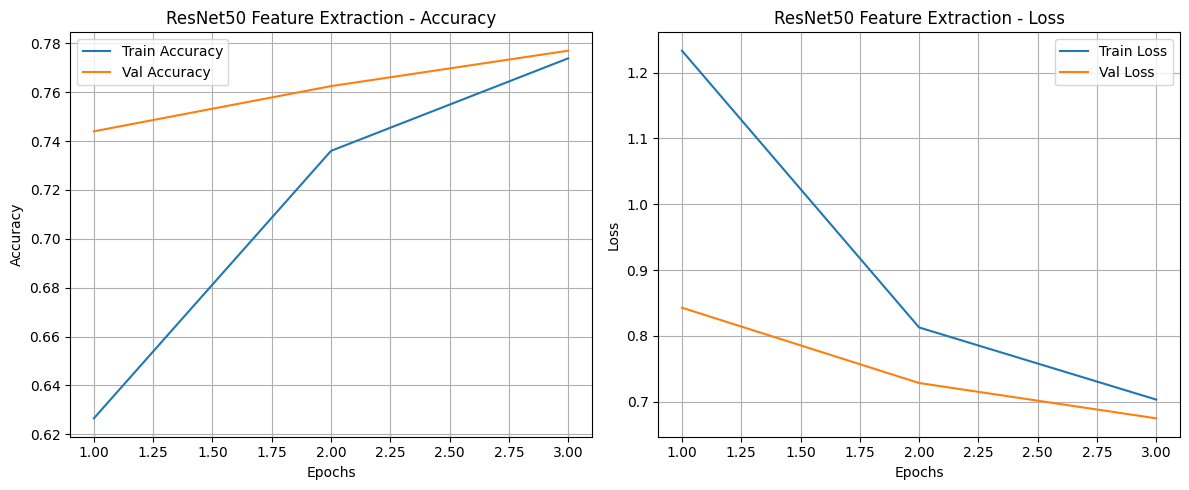

ResNet50 Feature Extraction Test Accuracy: 76.85 %
Training time: 114.66 seconds


In [ ]:
resnet50_feature_history, resnet50_feature_time = train_model(
    resnet50_feature_model, train_loader, val_loader,
    optimizer_name="adam", learning_rate=0.001,
    epochs=NUM_EPOCHS_MAIN, weight_decay=1e-4,
    early_stopping=False, verbose=True
)
plot_training_history(resnet50_feature_history, "ResNet50 Feature Extraction", "images/tutorial_07_resnet50_feature_extraction_curves.png")
y_true_res_fe, y_pred_res_fe = get_predictions(resnet50_feature_model, test_loader)
resnet50_feature_test_accuracy = accuracy_score(y_true_res_fe, y_pred_res_fe)
print("ResNet50 Feature Extraction Test Accuracy:", round(resnet50_feature_test_accuracy * 100, 2), "%")
print("Training time:", round(resnet50_feature_time, 2), "seconds")


# Part E — VGG16 Fine-Tuning

The last convolution block of VGG16 is unfrozen and trained with the new classifier.


In [ ]:
def build_vgg16_finetune():
    weights = models.VGG16_Weights.DEFAULT
    model = models.vgg16(weights=weights)
    for param in model.parameters():
        param.requires_grad = False
    for param in model.features[24:].parameters():
        param.requires_grad = True
    in_features = model.classifier[0].in_features
    model.classifier = nn.Sequential(
        nn.Linear(in_features, 512), nn.ReLU(), nn.Dropout(0.5), nn.Linear(512, 10)
    )
    for param in model.classifier.parameters():
        param.requires_grad = True
    return model


torch.manual_seed(SEED)
vgg16_finetune_model = build_vgg16_finetune().to(device)
print("VGG16 Fine-Tuning")
print("Total parameters:", count_total_parameters(vgg16_finetune_model))
print("Trainable parameters:", count_trainable_parameters(vgg16_finetune_model))


VGG16 Fine-Tuning
Total parameters: 27565386
Trainable parameters: 19930122


Epoch 1/3 | Train Loss: 0.6966 | Val Loss: 0.4760 | Train Acc: 76.12% | Val Acc: 84.70%
Epoch 2/3 | Train Loss: 0.2951 | Val Loss: 0.3667 | Train Acc: 89.78% | Val Acc: 87.95%
Epoch 3/3 | Train Loss: 0.1875 | Val Loss: 0.3722 | Train Acc: 93.85% | Val Acc: 87.15%


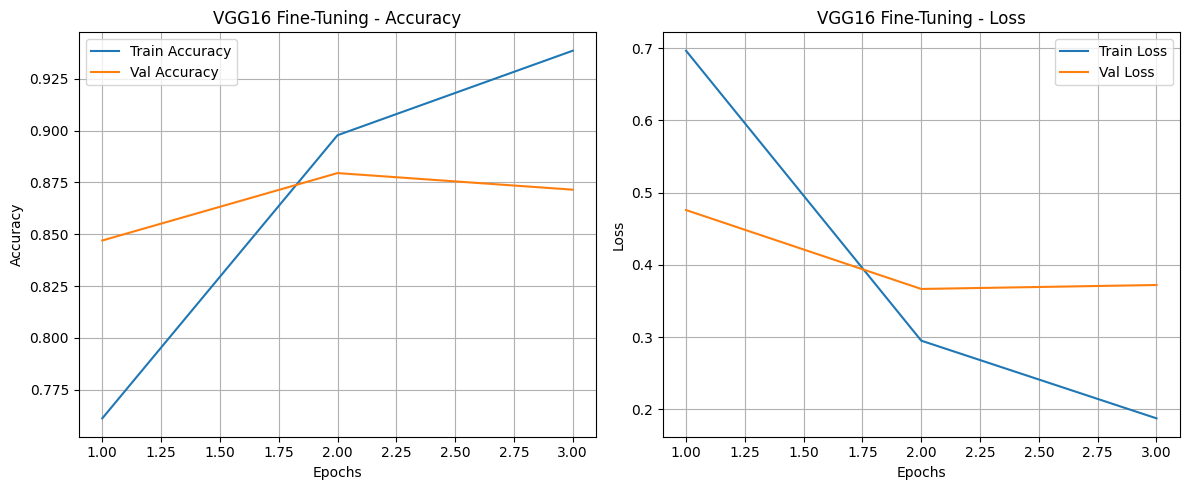

VGG16 Fine-Tuning Test Accuracy: 87.7 %
Training time: 175.44 seconds


In [ ]:
vgg16_finetune_history, vgg16_finetune_time = train_model(
    vgg16_finetune_model, train_loader, val_loader,
    optimizer_name="adam", learning_rate=1e-4,
    epochs=NUM_EPOCHS_MAIN, weight_decay=1e-4,
    early_stopping=False, verbose=True
)
plot_training_history(vgg16_finetune_history, "VGG16 Fine-Tuning", "images/tutorial_07_vgg16_finetuning_curves.png")
y_true_vgg_ft, y_pred_vgg_ft = get_predictions(vgg16_finetune_model, test_loader)
vgg16_finetune_test_accuracy = accuracy_score(y_true_vgg_ft, y_pred_vgg_ft)
print("VGG16 Fine-Tuning Test Accuracy:", round(vgg16_finetune_test_accuracy * 100, 2), "%")
print("Training time:", round(vgg16_finetune_time, 2), "seconds")


# Part F — Improved Fine-Tuning

Fine-tuning results can be improved using:

- Lower learning rate
- Early stopping
- Weight decay
- More epochs
- Better preprocessing
- Unfreezing more selected layers

This improved model unfreezes `layer3` and `layer4` of ResNet50 and uses dropout in the classifier.


In [ ]:
def build_resnet50_improved_finetune():
    weights = models.ResNet50_Weights.DEFAULT
    model = models.resnet50(weights=weights)
    for param in model.parameters():
        param.requires_grad = False
    in_features = model.fc.in_features
    model.fc = nn.Sequential(nn.Dropout(0.4), nn.Linear(in_features, 10))
    for param in model.layer3.parameters():
        param.requires_grad = True
    for param in model.layer4.parameters():
        param.requires_grad = True
    for param in model.fc.parameters():
        param.requires_grad = True
    return model


torch.manual_seed(SEED)
improved_finetune_model = build_resnet50_improved_finetune().to(device)
print("Improved ResNet50 Fine-Tuning")
print("Total parameters:", count_total_parameters(improved_finetune_model))
print("Trainable parameters:", count_trainable_parameters(improved_finetune_model))


Improved ResNet50 Fine-Tuning
Total parameters: 23528522
Trainable parameters: 22083594


Epoch 1/5 | Train Loss: 1.3186 | Val Loss: 0.4560 | Train Acc: 60.56% | Val Acc: 86.30%
Epoch 2/5 | Train Loss: 0.4002 | Val Loss: 0.3030 | Train Acc: 87.70% | Val Acc: 90.55%
Epoch 3/5 | Train Loss: 0.2117 | Val Loss: 0.2820 | Train Acc: 93.88% | Val Acc: 91.00%
Epoch 4/5 | Train Loss: 0.1397 | Val Loss: 0.2675 | Train Acc: 96.12% | Val Acc: 91.05%
Epoch 5/5 | Train Loss: 0.0947 | Val Loss: 0.2503 | Train Acc: 97.24% | Val Acc: 92.10%


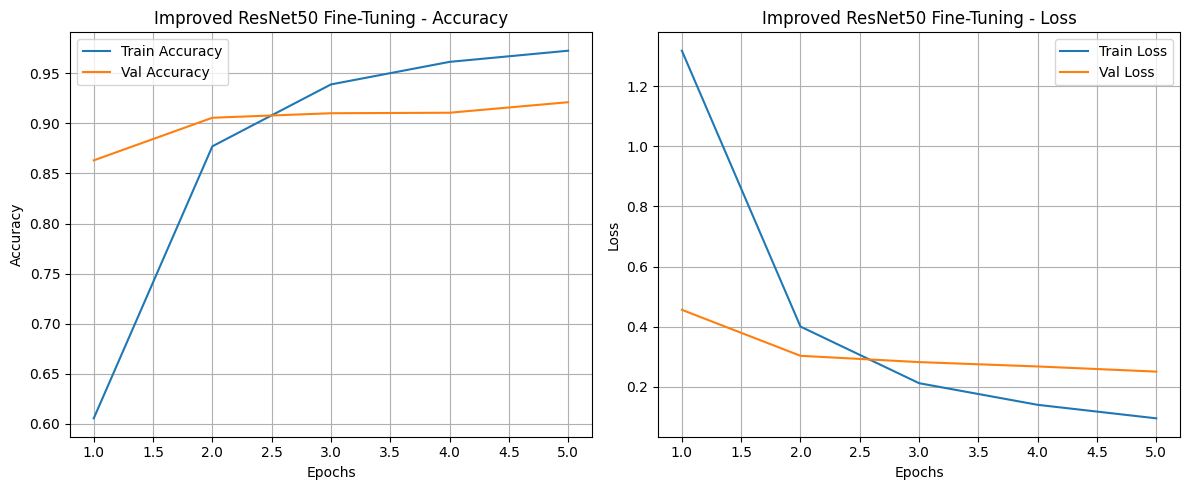

Improved Fine-Tuning Test Accuracy: 91.9 %
Training time: 214.21 seconds
Epochs trained: 5


In [ ]:
improved_finetune_history, improved_finetune_time = train_model(
    improved_finetune_model, train_loader, val_loader,
    optimizer_name="adam", learning_rate=5e-5,
    epochs=NUM_EPOCHS_IMPROVED, weight_decay=1e-4,
    early_stopping=True, patience=2, verbose=True
)
plot_training_history(improved_finetune_history, "Improved ResNet50 Fine-Tuning", "images/tutorial_07_improved_finetuning_curves.png")
y_true_improved, y_pred_improved = get_predictions(improved_finetune_model, test_loader)
improved_finetune_test_accuracy = accuracy_score(y_true_improved, y_pred_improved)
print("Improved Fine-Tuning Test Accuracy:", round(improved_finetune_test_accuracy * 100, 2), "%")
print("Training time:", round(improved_finetune_time, 2), "seconds")
print("Epochs trained:", len(improved_finetune_history["train_loss"]))


# Part G — Compare Results

In [ ]:
comparison_results = [
    {"Model": "Custom CNN", "Approach": "Trained from scratch", "Trainable Parameters": count_trainable_parameters(custom_model), "Final Train Acc": custom_history["train_accuracy"][-1], "Final Val Acc": custom_history["val_accuracy"][-1], "Test Accuracy": custom_test_accuracy, "Training Time (s)": custom_time},
    {"Model": "VGG16", "Approach": "Feature extraction", "Trainable Parameters": count_trainable_parameters(vgg16_feature_model), "Final Train Acc": vgg16_feature_history["train_accuracy"][-1], "Final Val Acc": vgg16_feature_history["val_accuracy"][-1], "Test Accuracy": vgg16_feature_test_accuracy, "Training Time (s)": vgg16_feature_time},
    {"Model": "ResNet50", "Approach": "Fine-tuning", "Trainable Parameters": count_trainable_parameters(resnet50_finetune_model), "Final Train Acc": resnet50_finetune_history["train_accuracy"][-1], "Final Val Acc": resnet50_finetune_history["val_accuracy"][-1], "Test Accuracy": resnet50_finetune_test_accuracy, "Training Time (s)": resnet50_finetune_time},
    {"Model": "ResNet50", "Approach": "Feature extraction", "Trainable Parameters": count_trainable_parameters(resnet50_feature_model), "Final Train Acc": resnet50_feature_history["train_accuracy"][-1], "Final Val Acc": resnet50_feature_history["val_accuracy"][-1], "Test Accuracy": resnet50_feature_test_accuracy, "Training Time (s)": resnet50_feature_time},
    {"Model": "VGG16", "Approach": "Fine-tuning", "Trainable Parameters": count_trainable_parameters(vgg16_finetune_model), "Final Train Acc": vgg16_finetune_history["train_accuracy"][-1], "Final Val Acc": vgg16_finetune_history["val_accuracy"][-1], "Test Accuracy": vgg16_finetune_test_accuracy, "Training Time (s)": vgg16_finetune_time},
    {"Model": "ResNet50 Improved", "Approach": "Improved fine-tuning", "Trainable Parameters": count_trainable_parameters(improved_finetune_model), "Final Train Acc": improved_finetune_history["train_accuracy"][-1], "Final Val Acc": improved_finetune_history["val_accuracy"][-1], "Test Accuracy": improved_finetune_test_accuracy, "Training Time (s)": improved_finetune_time}
]
comparison_df = pd.DataFrame(comparison_results)
comparison_df


,Model,Approach,Trainable Parameters,Final Train Acc,Final Val Acc,Test Accuracy,Training Time (s)
0,Custom CNN,Trained from scratch,620362,0.432875,0.4465,0.4580,84.893510
1,VGG16,Feature extraction,12850698,0.880875,0.8280,0.8225,186.294631
2,ResNet50,Fine-tuning,14985226,0.921625,0.8580,0.8580,133.162933
3,ResNet50,Feature extraction,20490,0.773875,0.7770,0.7685,114.664283
4,VGG16,Fine-tuning,19930122,0.938500,0.8715,0.8770,175.436376
5,ResNet50 Improved,Improved fine-tuning,22083594,0.972375,0.9210,0.9190,214.209947


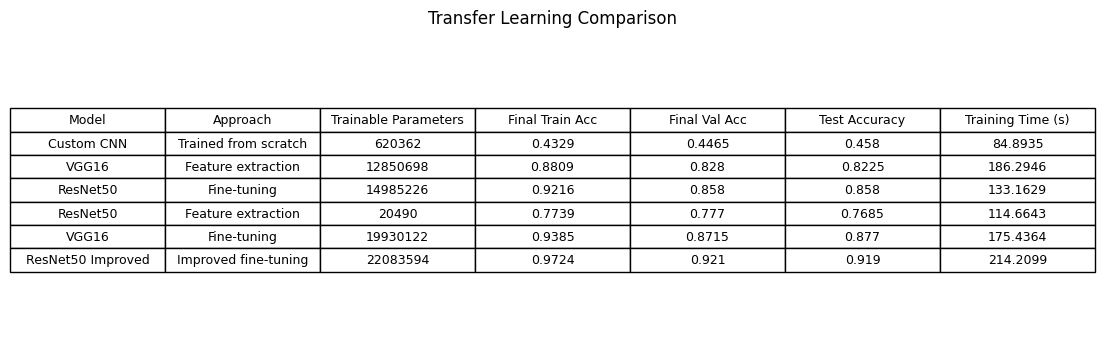

In [ ]:
comparison_image_df = comparison_df.copy()
for column in ["Final Train Acc", "Final Val Acc", "Test Accuracy", "Training Time (s)"]:
    comparison_image_df[column] = comparison_image_df[column].round(4)

save_dataframe_as_image(
    comparison_image_df,
    "images/tutorial_07_model_comparison_table.png",
    title="Transfer Learning Comparison"
)


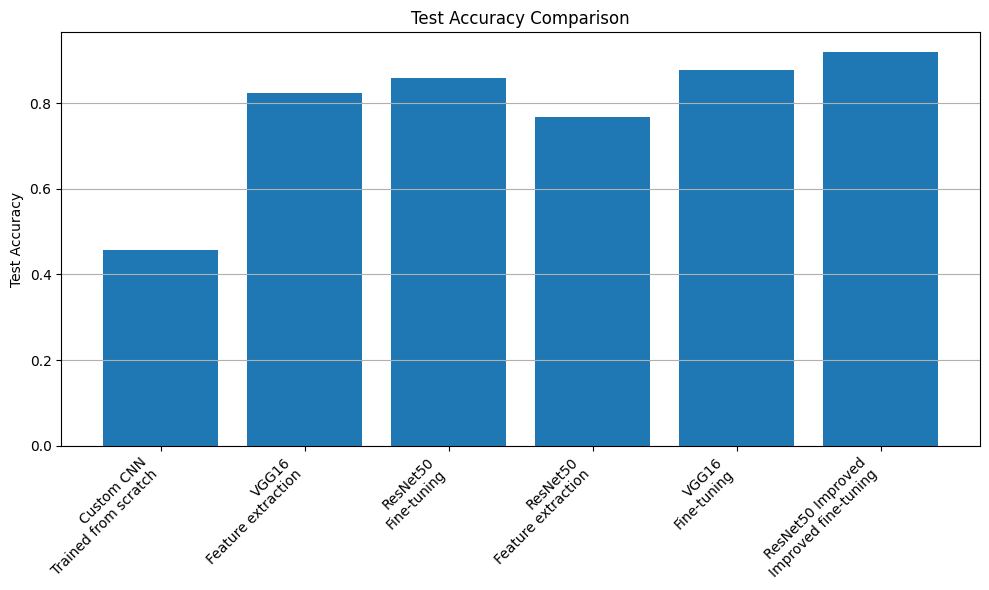

In [ ]:
plt.figure(figsize=(10, 6))

labels = comparison_df["Model"] + "\n" + comparison_df["Approach"]

plt.bar(labels, comparison_df["Test Accuracy"])
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy Comparison")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig("images/tutorial_07_test_accuracy_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Prediction Examples from the Best Model

In [ ]:
best_model_index = comparison_df["Test Accuracy"].idxmax()
best_model_name = comparison_df.loc[best_model_index, "Model"]
best_model_approach = comparison_df.loc[best_model_index, "Approach"]
print("Best model:", best_model_name, "-", best_model_approach)

model_lookup = {
    ("Custom CNN", "Trained from scratch"): custom_model,
    ("VGG16", "Feature extraction"): vgg16_feature_model,
    ("ResNet50", "Fine-tuning"): resnet50_finetune_model,
    ("ResNet50", "Feature extraction"): resnet50_feature_model,
    ("VGG16", "Fine-tuning"): vgg16_finetune_model,
    ("ResNet50 Improved", "Improved fine-tuning"): improved_finetune_model
}

best_model = model_lookup[(best_model_name, best_model_approach)]


Best model: ResNet50 Improved - Improved fine-tuning


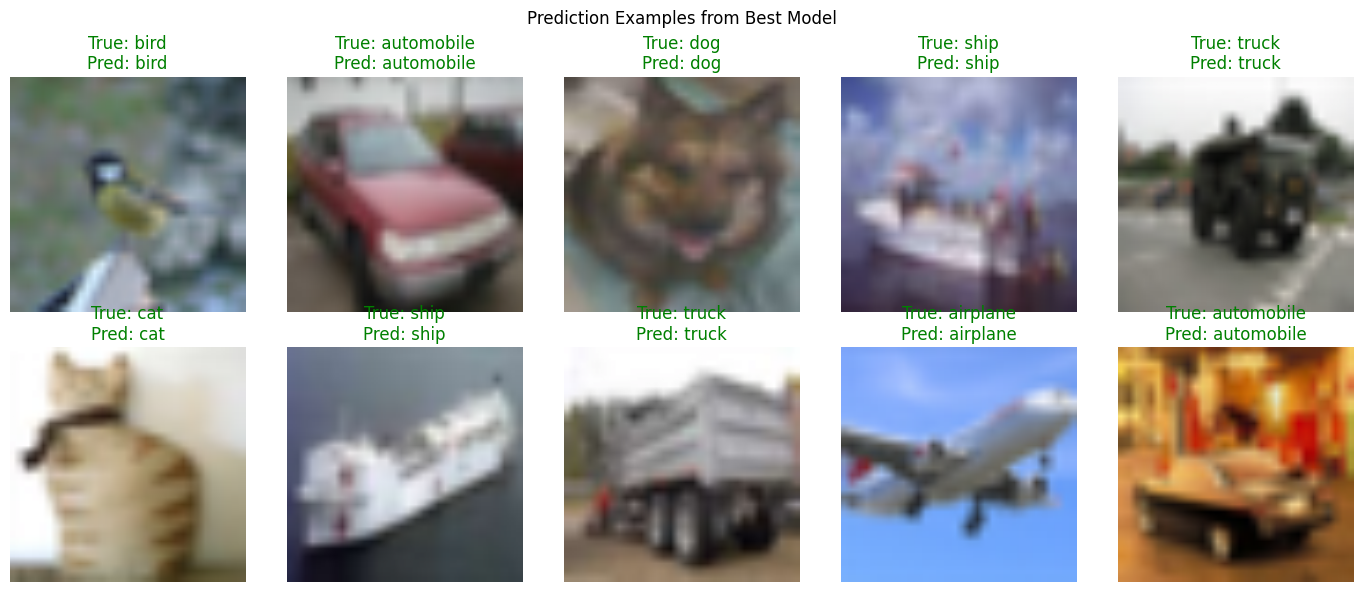

In [33]:
def visualize_predictions(model, dataset, n_images=10, filename="images/tutorial_07_prediction_examples.png"):
    model.eval()

    plt.figure(figsize=(14, 6))

    for i in range(n_images):
        image, true_label = dataset[i]
        image_input = image.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(image_input)
            _, predicted_label = torch.max(output, 1)

        # Unnormalize image for display
        image_np = image.clone()
        for channel, mean, std in zip(image_np, imagenet_mean, imagenet_std):
            channel.mul_(std).add_(mean)

        image_np = torch.clamp(image_np, 0, 1)

        color = "green" if predicted_label.item() == true_label else "red"

        plt.subplot(2, 5, i + 1)
        plt.imshow(image_np.permute(1, 2, 0).numpy())

        title_text = f"True: {class_names[true_label]}\nPred: {class_names[predicted_label.item()]}"
        plt.title(title_text, color=color)

        plt.axis("off")

    plt.suptitle("Prediction Examples from Best Model")
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


visualize_predictions(best_model, test_dataset, n_images=10)


# Final Observations

## Feature Extraction

Feature extraction freezes the pretrained model and only trains the new classification layers. This is faster and requires fewer trainable parameters.

## Fine-Tuning

Fine-tuning unfreezes some pretrained layers and updates them for the new dataset. This can improve performance, but it is slower and can overfit if the learning rate is too high or too many layers are unfrozen.

## Improving Fine-Tuning

Fine-tuning can be improved by using a lower learning rate, early stopping, weight decay, better preprocessing, more epochs, and carefully selecting which layers to unfreeze.

## Key Learning

Transfer learning is useful because pretrained models already contain strong image features learned from large datasets such as ImageNet. For CIFAR-10, the final classifier must be changed from 1000 ImageNet classes to 10 CIFAR-10 classes.
